Chebyshev Center Project
=====================================================
We will make a function that takes an input a set of points  $\{a_1,a_2,\dots,a_n\}\subseteq\mathbb{R}^n$ and outputs a point $c.$ This point $c$ is called the Chebyshev Center of the set and marks the center of the closed ball of smallest radius that contains each point in our set. 

In [ ]:
# Import Relevant Packages

# magic commands to import modules
# uncomment the following if executing this codeblock returns ModuleNotFoundError
#%pip install --upgrade pip
#%pip install numpy
#%pip install matplotlib
#%pip install cvxpy
#%pip install kagglehub
#%pip install pandas
# Packages
import kagglehub
import numpy as np
import matplotlib.pyplot as plt
import cvxpy as cp
import os

path = kagglehub.dataset_download("sarveshchhetri/student-lifestyle-vs-academic-performance-dataset")

/usr/local/python/3.12.1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#print(os.listdir(path))
#csv_path=os.path.join(path, "student_performance_finalscore.csv")
#data = np.genfromtxt(csv_path, delimiter=',', skip_header=1)
#data_relevant=data[:,[3,4,7,8]]

#data_study=data[:,3]
#data_screen=data[:,7]
#data_gpa=data[:,8]
#colors=np.where(data_gpa>3.9, 'red', 'blue')
#print(data_relevant.shape)
#print(data.shape)

In [3]:
#plt.figure(figsize=(10,10))
#plt.scatter(data_study,data_screen,c=colors)

# Defintions

(Euclidean Norm) For a point $x\in\mathbb{R}^n$ the "length" of the point is given by $$\|x\|_2=
    (\sum_{i=1}^{n} x_i^2)^{\frac{1}{2}} \text{ for } i=1,2,\dots, n$$

(Closed Ball) A closed ball of radius $r$ in $\mathbb{R}^n$ about a point $c$ is a set containing every point at most a distance of $r$ away from $c$. Symbolically,

$$\text{B}[c,r]=\{x\in\mathbb{R}^n~:~\|x-c\|_2\leq r\}$$



# Motivation

Our goal is to minimize $r$ given the contraint(s),
    $$\|c-a_i\|\leq r$$
Hence, we can approach this problem as a convex optimization problem and will make use of the CVXPY Python Package, that is, we have the following convex problem. Let $c$ denote our Chebyshev center, and $a_i$ be a point in the set of which we are trying to find the center.
    $$
        \begin{align*}
            &\underset{c,r}{\text{min}}&&r\\
            &\text{s.t.} &&\|c-a_i\|\leq r \text{ for all } i=1,2,\dots
        \end{align*}
    $$

In [4]:
# Define Function
def chebyshev_center(points):
    #This function will take in a list of points in R^n and output a point c
    #representing the center of the ball of minimal radius containing every 
    #vector in our list
    points=np.array(points)
    r=cp.Variable()
    c=cp.Variable(len(points[0])) #This makes our point c exist in the same space
                                  #as points in our list
    objective = cp.Minimize(r)
    
    #Make our set of contraints
    constraints=[]
    for i in range(len(points)):
        ai = points[i]
        constraints.append(cp.norm(c-ai,2)<=r)
    
    #solve
    problem=cp.Problem(objective,constraints)
    chebyshev_radius=problem.solve()

    print(f'The ball of radius r={chebyshev_radius:.2f} centered at the Chebyshev Center c={np.round(c.value,5)} contains each point in the set.')

    if len(points[0])==2:
        print('\n Your data set contains 2-D points; lets graph it!')

        plt.figure(figsize=(6,6))
        #points of argument
        plt.scatter(points[:,0],points[:,1],s=25,c="red",marker='o',label='Dataset')
        
        #chebyshev center
        plt.scatter(c.value[0],c.value[1],s=100,c='blue',marker='*',label='Chebyshev Center')

        #chebyshev circle
        theta=np.linspace(0,2*np.pi,100)
        plt.plot(r.value*np.cos(theta)+c.value[0],r.value*np.sin(theta)+c.value[1],color='blue')

        plt.legend()
        plt.title('Chebyshev Center')
        plt.show()

# Examples

### Example 1: Circle

The ball of radius r=3.00 centered at the Chebyshev Center c=[-0. -0.] contains each point in the set.

 Your data set contains 2-D points; lets graph it!


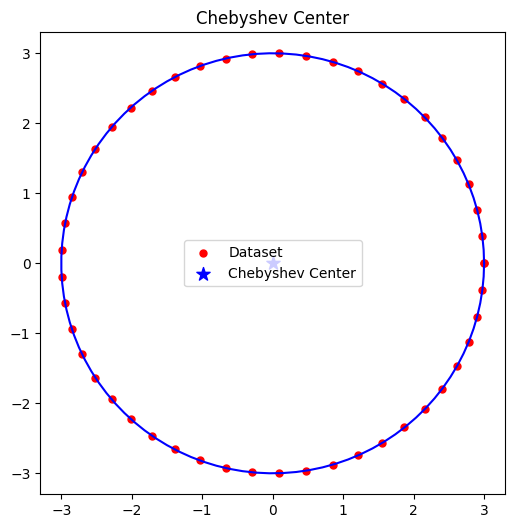

In [5]:
theta1=np.linspace(0,2*np.pi,50)
test1=[]
for t in theta1:
    test1.append([3*np.cos(t), 3*np.sin(t)])
                 
chebyshev_center(test1)

### Example 2: A set of random points in $\mathbb{R}^2$

The ball of radius r=3.14 centered at the Chebyshev Center c=[-0.59193 -0.15588] contains each point in the set.

 Your data set contains 2-D points; lets graph it!


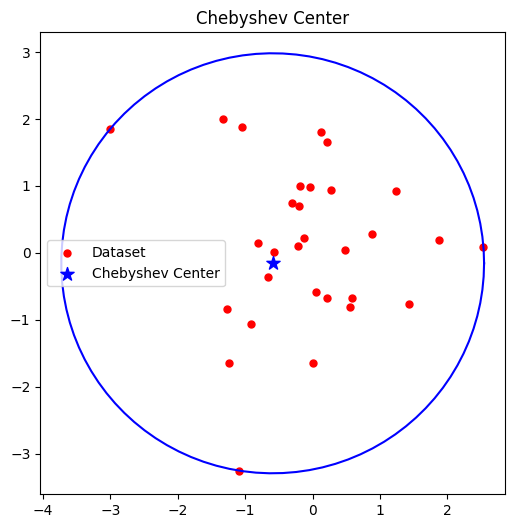

In [6]:
chebyshev_center(np.random.randn(30,2))

### Example 3: Real World Application